# HOUSE RENT PREDICTION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## read the data set

In [3]:
data=pd.read_csv("Hyderabad_House_Data (4).csv")

## to print all coloumns in data set

In [4]:
data.columns

Index(['Unnamed: 0', 'Bedrooms', 'Washrooms', 'Furnishing', 'Tennants', 'Area',
       'Price', 'Locality'],
      dtype='object')

## to print first 5 rows in given data set

In [5]:
data.head()

,Unnamed: 0,Bedrooms,Washrooms,Furnishing,Tennants,Area,Price,Locality
0,0,3 BHK Builder Floor,2,Furnished,Bachelors/Family,1800 sqft,"34,000","Bhagyalaxmi Nagar, Kavadiguda"
1,1,3 BHK Apartment,2,Semi-Furnished,Family,2500 sqft,"45,000","Gachibowli, Outer Ring Road"
2,2,1 BHK Builder Floor,Immediately,Furnished,Bachelors/Family,read more,"18,000",Gachibowli
3,3,3 BHK Apartment,Immediately,Furnished,Bachelors/Family,2160 sqft,"40,000","Moosapet, NH"
4,4,3 BHK Apartment,2,Semi-Furnished,Family,1580 sqft,"23,000",Raghavendra Colony kondapur


## to print last 5 rows in given data set

In [6]:
data.tail()

,Unnamed: 0,Bedrooms,Washrooms,Furnishing,Tennants,Area,Price,Locality
1166,1166,2 BHK Apartment,1,Unfurnished,Family,900 sqft,"15,000",KPHB Road
1167,1167,1 BHK Apartment,1,Semi-Furnished,Bachelors/Family,East Facing Property,"10,000","Miyapur, NH"
1168,1168,3 BHK Apartment,1,Unfurnished,Bachelors,1515 sqft,"14,000","Pragathi Nagar, Kukatpally"
1169,1169,3 BHK Apartment,From Nov '19,Family,3,1500 sqft,"16,000","Habsiguda, NH"
1170,1170,2 BHK Apartment,2,Semi-Furnished,Bachelors/Family,1100 sqft,"12,000","Umas Aadya and Arha Mensions, Kukatpally, NH"


## to print how  many rows and colounms in given data set

In [7]:
data.shape

(1171, 8)

## to print all the details in the given data

In [8]:
data.describe

<bound method NDFrame.describe of       Unnamed: 0             Bedrooms     Washrooms      Furnishing  \
0              0  3 BHK Builder Floor             2       Furnished   
1              1      3 BHK Apartment             2  Semi-Furnished   
2              2  1 BHK Builder Floor   Immediately       Furnished   
3              3      3 BHK Apartment   Immediately       Furnished   
4              4      3 BHK Apartment             2  Semi-Furnished   
...          ...                  ...           ...             ...   
1166        1166      2 BHK Apartment             1     Unfurnished   
1167        1167      1 BHK Apartment             1  Semi-Furnished   
1168        1168      3 BHK Apartment             1     Unfurnished   
1169        1169      3 BHK Apartment  From Nov '19          Family   
1170        1170      2 BHK Apartment             2  Semi-Furnished   

              Tennants                  Area   Price  \
0     Bachelors/Family             1800 sqft  34,000   
1

## to print coloumns with values in given data set 

In [9]:
data.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms     21
Furnishing     0
Tennants       1
Area          22
Price          0
Locality       0
dtype: int64

## to remove washroomd data value

In [10]:
data['Washrooms']=pd.to_numeric(data['Washrooms'],errors='coerce')

## to place the value

In [11]:
data['Washrooms']=data['Washrooms'].fillna(data['Washrooms'].median())

## to check the washrooms value is null or not

In [12]:
data.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms      0
Furnishing     0
Tennants       1
Area          22
Price          0
Locality       0
dtype: int64

## to remove the tennants values

In [13]:
data['Tennants']=pd.to_numeric(data['Tennants'],errors='coerce')

## to replace the value

In [14]:
data['Tennants']=data['Tennants'].fillna(data['Tennants'].median())

## to check the tennants value is null or not

In [15]:
data.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms      0
Furnishing     0
Tennants       0
Area          22
Price          0
Locality       0
dtype: int64

## replacing the column with the extracted digit text.


In [16]:
data['Area']=data['Area'].astype(str).str.extract('(\d+)')

## converts the Area column values from strings to numeric 

In [17]:
data['Area']=pd.to_numeric(data['Area'],errors='coerce')

## replaces all missing values in the Area column with the column's median value.

In [18]:
data['Area']=data['Area'].fillna(data['Area'].median())

In [19]:
data[["Washrooms","Area"]].isnull().sum()

Washrooms    0
Area         0
dtype: int64

In [20]:
data['price']=(
    data['Price']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
)

In [21]:
data['Price']=data['price'].astype(float)

In [22]:
data['Price'].dtype

dtype('float64')

In [23]:
data['Price'].apply(type).value_counts()

Price
<class 'float'>    1171
Name: count, dtype: int64

In [24]:
x=data.drop('Price',axis=1)
y=data['Price']

In [25]:
x=pd.get_dummies(x,drop_first=True)

In [26]:
# Save the column names for later use in prediction
columns = x.columns
joblib.dump(columns, 'columns.pkl')

['columns.pkl']

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [28]:
# Save the scaler for later use in prediction
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
# Save the trained model for later use
joblib.dump(model, 'model.pkl')

['model.pkl']

In [32]:
print(x_train.dtype)
print(y_train.dtype)

float64
float64


In [33]:
y_pred = model.predict(x_test)


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [35]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", r2)

MAE : 937.9845196482457
MSE : 21936953.013353445
RMSE : 0.818514602860911


In [36]:
new_house = pd.DataFrame({
    'Area' : [1400],
    'Bedrooms' : [6],
    'Washrooms' : [3]
})

new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=x.columns, fill_value=0)

new_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_scaled)
print("predicted House Price:",predicted_price[0])

predicted House Price: 10020.655157318932


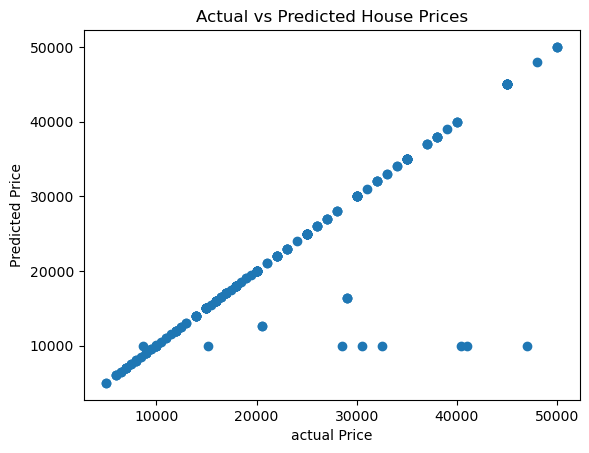

In [37]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual Price")
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [38]:
import joblib

# Load the saved objects
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')
columns = joblib.load('columns.pkl')

# For prediction on new data
new_house = pd.DataFrame({
    'Area': [1400],
    'Bedrooms': [6],
    'Washrooms': [3]
})
new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=columns, fill_value=0)
new_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_scaled)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 10020.655157318932
